In [40]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pylab as plt
%matplotlib inline
from rubin_scheduler.scheduler.utils import CurrentAreaMap
import healpy as hp
import rubin_sim.splat as maf

In [42]:
db = "euclid_later_v5.2.0_1yrs.db"
con = sqlite3.connect(db)
df = pd.read_sql("select * from observations;", con)
con.close()
visits_array = df.to_records(index=False)

In [5]:
df

,observationId,fieldRA,fieldDec,observationStartMJD,flush_by_mjd,visitExposureTime,band,filter,rotSkyPos,rotSkyPos_desired,...,sunDec,moonRA,moonDec,moonDistance,solarElong,moonPhase,cummTelAz,observation_reason,science_program,cloud_extinction
0,0,43.149314,-80.851813,61131.981586,61151.664337,30.0,r,r_57,311.688482,0.0,...,4.694457,189.434677,-6.303226,91.321089,86.948088,98.785817,-169.781640,too_neutrino_39_i2,BLOCK-419,0.0
1,1,43.149314,-80.851813,61131.983601,61151.653920,30.0,g,g_6,311.688482,0.0,...,4.695233,189.455067,-6.316158,91.309995,86.948705,98.787702,-169.781640,too_neutrino_39_i1,BLOCK-419,0.0
2,2,43.149314,-80.851813,61131.983995,61151.653920,30.0,g,g_6,311.688482,0.0,...,4.695385,189.459044,-6.318689,91.307823,86.948826,98.788054,-169.781640,too_neutrino_39_i1,BLOCK-419,0.0
3,3,43.149314,-80.851813,61131.984390,61151.653920,30.0,g,g_6,311.688482,0.0,...,4.695537,189.463017,-6.321220,91.305650,86.948947,98.788399,-169.781640,too_neutrino_39_i1,BLOCK-419,0.0
4,4,43.149314,-80.851813,61131.984784,61151.653920,30.0,g,g_6,311.688482,0.0,...,4.695689,189.466985,-6.323750,91.303477,86.949068,98.788738,-169.781640,too_neutrino_39_i1,BLOCK-419,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
201389,201389,321.751484,-55.209401,61496.415668,0.000000,30.0,r,r_57,172.173655,0.0,...,4.378843,310.086453,-19.368342,36.915057,71.649184,35.365268,-126.813453,singles_r,BLOCK-419,0.0
201390,201390,319.185210,-48.981430,61496.416101,0.000000,30.0,r,r_57,168.135481,0.0,...,4.379010,310.089940,-19.367040,30.504873,69.249930,35.363551,-135.370915,singles_r,BLOCK-419,0.0
201391,201391,320.219446,-52.120941,61496.416522,0.000000,30.0,r,r_57,170.725231,0.0,...,4.379173,310.093328,-19.365771,33.698651,70.512551,35.361883,-130.937336,singles_r,BLOCK-419,0.0
201392,201392,300.129243,-61.625005,61496.417039,0.000000,30.0,r,r_57,203.527929,0.0,...,4.379373,310.097484,-19.364211,42.834299,84.576832,35.359837,-110.421408,singles_r,BLOCK-419,0.0


In [15]:
dt = np.where((df["sunAlt"] < -18) & (df["moonAlt"] < 0) & (df["seeingFwhmEff"] < 1.2))[0]

In [16]:
dt

array([  1940,   1941,   1942, ..., 201011, 201012, 201013],
      shape=(67518,))

In [17]:
bands = df["band"].values[dt]

In [18]:
for band in np.unique(bands):
    nb = np.size(np.where(bands == band)[0])
    print(band, nb)

g 20361
i 9035
r 10951
u 17816
y 2518
z 6837


In [21]:
print(np.size(bands))

67518


(array([   79.,  1011.,  3849.,  6942.,  9398., 10259., 11028.,  9768.,
         8515.,  6669.]),
 array([0.48316744, 0.55484873, 0.62653003, 0.69821132, 0.76989261,
        0.84157391, 0.9132552 , 0.98493649, 1.05661779, 1.12829908,
        1.19998037]),
 <BarContainer object of 10 artists>)

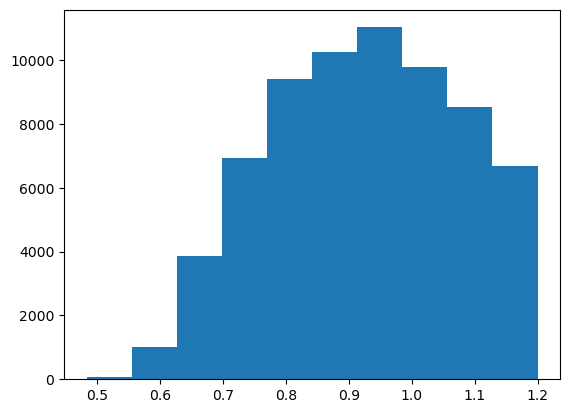

In [19]:
plt.hist(df["seeingFwhmEff"].values[dt])

In [29]:
nside = 32
sag = CurrentAreaMap(nside=nside)
sky_maps, labels = sag.return_maps()


In [32]:
u_area = np.size(np.where(sky_maps["u"] > 0)[0]) * hp.nside2pixarea(nside, degrees=True)
g_area = np.size(np.where(sky_maps["g"] > 0)[0]) * hp.nside2pixarea(nside, degrees=True)

In [33]:
u_area

np.float64(24064.227395494574)

In [34]:
g_area

np.float64(27176.32823193758)

In [35]:
rubin_fov = 9.6  # sq deg

In [39]:
print("visits to cover u and g = ", (u_area + g_area)/rubin_fov)

visits to cover u and g =  5337.557877857516


In [49]:
sub_data = visits_array[np.where((visits_array["band"] == "u") )]
sl = maf.Slicer()
metric = maf.CountMetric()
hp_array = sl(sub_data, metric)


np.float64(8.0)

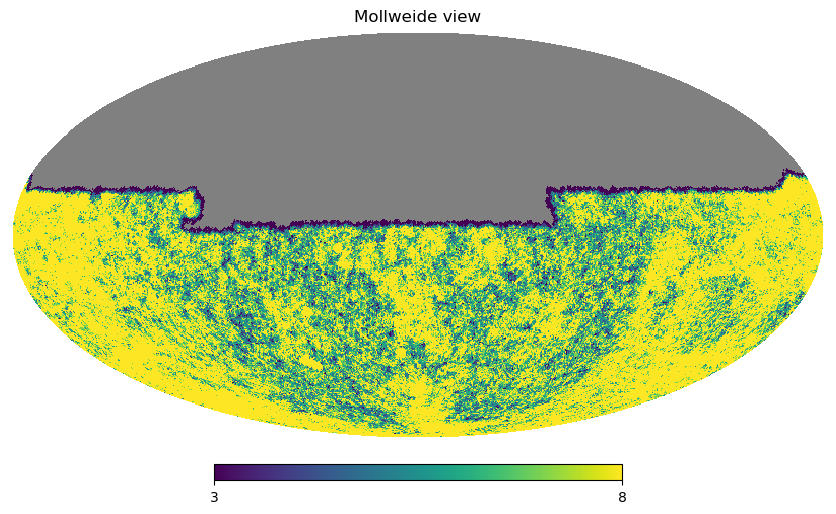

In [54]:
hp.mollview(hp_array, max=8, min=3)
gp = np.where(hp_array > 0)
np.median(hp_array[gp])

(array([    0.,   933.,   875.,  1257.,  3660.,  9621., 17926., 22318.,
        37891.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

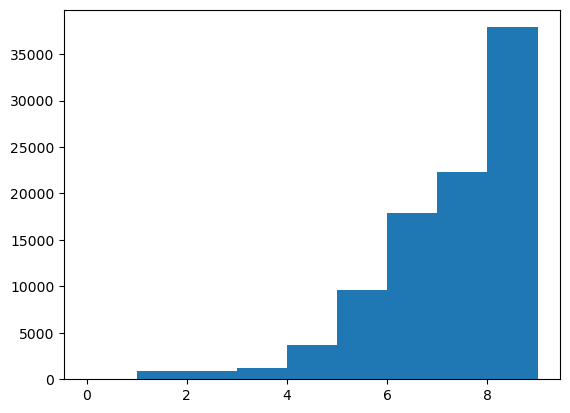

In [52]:
plt.hist(hp_array, bins=np.arange(10))